In [10]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [11]:
# ── 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_session_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data

def load_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_AMATEUR = r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026'
BASE_PROF    = r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026'

PATHS = {
    'amateur': {s: os.path.join(BASE_AMATEUR, s) for s in ['ss01','ss02','ss03']},
    'prof':    {s: os.path.join(BASE_PROF,    s) for s in ['ss01','ss02','ss03']},
}

maps = {}
complete = {}
for group in ['amateur', 'prof']:
    m1 = scan_session_folder(PATHS[group]['ss01'])
    m2 = scan_session_folder(PATHS[group]['ss02'])
    m3 = scan_session_folder(PATHS[group]['ss03'])
    maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f"[{group}] 完整 subject：{len(complete[group])} 人")

print("\n載入資料...")
X_a1, X_a2, X_a3 = load_group(*maps['amateur'], complete['amateur'])
X_p1, X_p2, X_p3 = load_group(*maps['prof'],    complete['prof'])
print("完成")

[amateur] 完整 subject：28 人
[prof] 完整 subject：8 人

載入資料...
完成


In [12]:
# ── 特徵提取 & 準備 LOSO 資料集 ──

CLASS_NAMES = ['amateur', 'prof']

def extract_features(X):
    """(n, 32ch, 39time, 5bands) → (n, 160)"""
    X = np.log(X + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    return X.reshape(len(X), -1)

n_a = len(complete['amateur'])
n_p = len(complete['prof'])
n_total = n_a + n_p

# 特徵提取（每個 session）
Fa1, Fa2, Fa3 = extract_features(X_a1), extract_features(X_a2), extract_features(X_a3)
Fp1, Fp2, Fp3 = extract_features(X_p1), extract_features(X_p2), extract_features(X_p3)

# 為每個 subject 的 3 個 session 堆疊
# amateur: (28, 3, 160) → (84, 160)
X_a_all = np.vstack([Fa1, Fa2, Fa3])  # (84, 160)
X_p_all = np.vstack([Fp1, Fp2, Fp3])  # (24, 160)
X_all = np.vstack([X_a_all, X_p_all]) # (108, 160)

# 標籤：0=amateur, 1=prof
y_all = np.concatenate([np.zeros(n_a * 3), np.ones(n_p * 3)])

# Subject ID 列表（每個 session 對應一個 subject）
subject_ids = complete['amateur'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),  # 每個 amateur subject 重複 3 次
    np.repeat(complete['prof'], 3),     # 每個 prof subject 重複 3 次
])

print(f"X_all shape: {X_all.shape}")
print(f"Total subjects: {n_total}")
print(f"  Amateur: {n_a}, Prof: {n_p}")
print(f"y 分佈: {np.bincount(y_all.astype(int)).tolist()}")
print(f"\nLOSO 將執行 {n_total} 次迴圈")

X_all shape: (108, 160)
Total subjects: 36
  Amateur: 28, Prof: 8
y 分佈: [84, 24]

LOSO 將執行 36 次迴圈


In [13]:
# ── LOSO 訓練 (160 dims) ──

def make_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=40)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced', random_state=42)),
    ])

results_160   = []
all_preds_160 = []
all_true_160  = []
test_subjects_160 = []

for test_subject in subject_ids:
    # 分離該 subject 的測試資料和其他人的訓練資料
    test_mask  = subject_split == test_subject
    train_mask = ~test_mask

    X_tr, y_tr = X_all[train_mask], y_all[train_mask].astype(int)
    X_te, y_te = X_all[test_mask],  y_all[test_mask].astype(int)

    pipe = make_pipeline()
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro', zero_division=0)

    results_160.append({'acc': acc, 'f1': f1, 'subject': test_subject})
    all_preds_160.extend(preds)
    all_true_160.extend(y_te)
    test_subjects_160.append(test_subject)

mean_acc_160 = np.mean([r['acc'] for r in results_160])
mean_f1_160  = np.mean([r['f1']  for r in results_160])
all_preds_160 = np.array(all_preds_160)
all_true_160 = np.array(all_true_160)

print(f">>> 160 dims LOSO 平均  Acc={mean_acc_160:.3f}  F1={mean_f1_160:.3f}")
print(f"\nPer-subject 結果 (前 10):")
for i, r in enumerate(results_160[:10]):
    print(f"  {r['subject']:<10s}: Acc={r['acc']:.3f}  F1={r['f1']:.3f}")

>>> 160 dims LOSO 平均  Acc=0.898  F1=0.829

Per-subject 結果 (前 10):
  sub-22    : Acc=1.000  F1=1.000
  sub-23    : Acc=1.000  F1=1.000
  sub-24    : Acc=1.000  F1=1.000
  sub-33    : Acc=1.000  F1=1.000
  sub-38    : Acc=1.000  F1=1.000
  sub-39    : Acc=1.000  F1=1.000
  sub-40    : Acc=1.000  F1=1.000
  sub-41    : Acc=1.000  F1=1.000
  sub-42    : Acc=1.000  F1=1.000
  sub-43    : Acc=1.000  F1=1.000


整體混淆矩陣 (160 dims):
[[78  6]
 [ 5 19]]

Classification Report (160 dims):
              precision    recall  f1-score   support

     amateur       0.94      0.93      0.93        84
        prof       0.76      0.79      0.78        24

    accuracy                           0.90       108
   macro avg       0.85      0.86      0.85       108
weighted avg       0.90      0.90      0.90       108



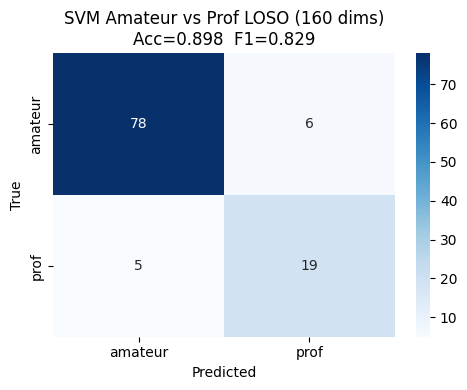

In [14]:
# ── 160 dims 混淆矩陣 & 詳細報告 ──

cm = confusion_matrix(all_true_160, all_preds_160, labels=[0, 1])
print(f"整體混淆矩陣 (160 dims):")
print(cm)
print(f"\nClassification Report (160 dims):")
print(classification_report(all_true_160, all_preds_160, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'SVM Amateur vs Prof LOSO (160 dims)\nAcc={mean_acc_160:.3f}  F1={mean_f1_160:.3f}')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_amateur_prof_loso_160_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── top10ch_all_bands 特徵提取 ──

BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
TOP_CHS = [0, 6, 7, 10, 13, 14, 21, 22, 28, 31]

def extract_selected(X_raw, channels, bands):
    X = np.log(X_raw + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    X = X[:, channels, :]
    X = X[:, :, bands]
    return X.reshape(len(X), -1)

# 重新提取所有原始資料
raw_a = [X_a1, X_a2, X_a3]
raw_p = [X_p1, X_p2, X_p3]

# 特徵提取
ch_sel = [0, 6, 7, 10, 13, 14, 21, 22, 28, 31]
bands_sel = [0, 1, 2, 3, 4]
pca_n = 20

F_a_sel = [extract_selected(Xr, ch_sel, bands_sel) for Xr in raw_a]
F_p_sel = [extract_selected(Xr, ch_sel, bands_sel) for Xr in raw_p]

X_a_sel = np.vstack(F_a_sel)
X_p_sel = np.vstack(F_p_sel)
X_sel = np.vstack([X_a_sel, X_p_sel])

print(f"top10ch_all_bands 特徵維度: {X_sel.shape[1]}")

top10ch_all_bands 特徵維度: 50


In [16]:
# ── LOSO 訓練 (top10ch_all_bands) ──

results_top   = []
all_preds_top = []
all_true_top  = []

for test_subject in subject_ids:
    test_mask  = subject_split == test_subject
    train_mask = ~test_mask

    X_tr, y_tr = X_sel[train_mask], y_all[train_mask].astype(int)
    X_te, y_te = X_sel[test_mask],  y_all[test_mask].astype(int)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=pca_n)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced', random_state=42)),
    ])
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro', zero_division=0)

    results_top.append({'acc': acc, 'f1': f1, 'subject': test_subject})
    all_preds_top.extend(preds)
    all_true_top.extend(y_te)

mean_acc_top = np.mean([r['acc'] for r in results_top])
mean_f1_top  = np.mean([r['f1']  for r in results_top])
all_preds_top = np.array(all_preds_top)
all_true_top = np.array(all_true_top)

print(f">>> top10ch_all_bands LOSO 平均  Acc={mean_acc_top:.3f}  F1={mean_f1_top:.3f}")
print(f"\nPer-subject 結果 (前 10):")
for i, r in enumerate(results_top[:10]):
    print(f"  {r['subject']:<10s}: Acc={r['acc']:.3f}  F1={r['f1']:.3f}")

>>> top10ch_all_bands LOSO 平均  Acc=0.917  F1=0.850

Per-subject 結果 (前 10):
  sub-22    : Acc=1.000  F1=1.000
  sub-23    : Acc=1.000  F1=1.000
  sub-24    : Acc=1.000  F1=1.000
  sub-33    : Acc=1.000  F1=1.000
  sub-38    : Acc=1.000  F1=1.000
  sub-39    : Acc=1.000  F1=1.000
  sub-40    : Acc=1.000  F1=1.000
  sub-41    : Acc=1.000  F1=1.000
  sub-42    : Acc=1.000  F1=1.000
  sub-43    : Acc=1.000  F1=1.000


整體混淆矩陣 (top10ch_all_bands):
[[79  5]
 [ 4 20]]

Classification Report (top10ch_all_bands):
              precision    recall  f1-score   support

     amateur       0.95      0.94      0.95        84
        prof       0.80      0.83      0.82        24

    accuracy                           0.92       108
   macro avg       0.88      0.89      0.88       108
weighted avg       0.92      0.92      0.92       108



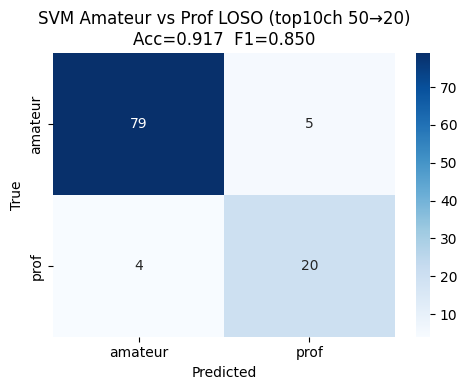

In [17]:
# ── top10ch_all_bands 混淆矩陣 & 詳細報告 ──

cm = confusion_matrix(all_true_top, all_preds_top, labels=[0, 1])
print(f"整體混淆矩陣 (top10ch_all_bands):")
print(cm)
print(f"\nClassification Report (top10ch_all_bands):")
print(classification_report(all_true_top, all_preds_top, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'SVM Amateur vs Prof LOSO (top10ch 50→20)\nAcc={mean_acc_top:.3f}  F1={mean_f1_top:.3f}')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_amateur_prof_loso_top10ch_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── LOSO 結果比較 ──

print("\n" + "="*60)
print("Amateur vs Prof LOSO 特徵配置比較")
print("="*60)
print(f"{'配置':<30s} {'Dims':>6s}  {'Acc':>6s}  {'F1':>6s}")
print("-"*60)
print(f"{'160 dims (all channels)':<30s} {160:6d}  {mean_acc_160:6.3f}  {mean_f1_160:6.3f}")
print(f"{'top10ch_all_bands (→20)':<30s} {50:6d}  {mean_acc_top:6.3f}  {mean_f1_top:6.3f}")
print("="*60)

# Per-subject 統計
print("\n" + "="*60)
print("Per-Subject 準確度分佈")
print("="*60)
accs_160 = [r['acc'] for r in results_160]
accs_top = [r['acc'] for r in results_top]
print(f"160 dims: min={np.min(accs_160):.3f}, max={np.max(accs_160):.3f}, std={np.std(accs_160):.3f}")
print(f"top10ch:  min={np.min(accs_top):.3f}, max={np.max(accs_top):.3f}, std={np.std(accs_top):.3f}")
print("="*60)


Amateur vs Prof LOSO 特徵配置比較
配置                               Dims     Acc      F1
------------------------------------------------------------
160 dims (all channels)           160   0.898   0.829
top10ch_all_bands (→20)            50   0.917   0.850

Per-Subject 準確度分佈
160 dims: min=0.333, max=1.000, std=0.172
top10ch:  min=0.667, max=1.000, std=0.144
